**Machine Learning** **Assignment 2**

---



**Part 1: Implementation Questions**

**Q1:** Download the following dataset diabetes (1).csv - Google Drive. ( 10 Marks )

In [ ]:
import pandas as pd
# Load the dataset
file_path = "/content/sample_data/diabetes (1).csv"
df = pd.read_csv(file_path)
Original_df = df

**Understand the data**

Before start preprocessing, it's essential to have a good understanding of our data. This includes knowing the data types of each column, the distribution of values, the presence of missing values, and the relationships between features.

In [ ]:
def data_understand():
  # Get the size (total number of elements)
  size = df.size
  print("Size of the data:", size)

  # Check the shape of the data (number of rows and columns)
  print("Shape of the data:", df.shape)

  # Check data types of columns
  print("\nData types of columns:\n", df.dtypes)

  print()
  # Check descriptive statistics
  print("\nDescriptive statistics:\n", df.describe())

  print()
  # Print the first few rows to get an overview
  print("\nFirst 5 rows:\n", df.head())

  print()
  # Check missing values
  missing_values = df.isnull().sum()
  if missing_values.any():
    print("\nMissing values:\n", missing_values)
  else:
    print("No missing values found.")

  # Find Duplicate Rows:
  duplicate_rows = df[df.duplicated()]

  if duplicate_rows.empty:
    print("No duplicate rows found.")
  else:
    # Print the Size (Number) of Duplicates:
    print("Number of duplicate rows:", duplicate_rows.shape[0])
    print()

data_understand()

Size of the data: 6912
Shape of the data: (768, 9)

Data types of columns:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Descriptive statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250

**Exploratory Data Analysis (EDA):**

Reasoning: EDA involves visualizing the data to identify patterns, relationships, and potential outliers. This step often involves creating histograms, scatter plots, box plots, and calculating correlation matrices.
Code:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plots histograms for numerical features in a DataFrame
def plot_histograms(df):
  for column in df.select_dtypes(include=['number']).columns:
    plt.figure()
    plt.hist(df[column])
    plt.title(f'Histogram of {column}')
    plt.show()

# Plots a histogram for a specific column in a DataFrame
def plot_histogram(df, column_name):
  plt.figure()
  plt.hist(df[column_name])
  plt.title(f'Histogram of {column_name}')
  plt.xlabel(column_name)
  plt.ylabel('Frequency')
  plt.show()

# Plots a scatter plot matrix for numerical features in a DataFrame
def plot_scatter_matrix(df):
  sns.pairplot(df)
  plt.show()

# Plots a correlation matrix for numerical features in a DataFrame
def plot_correlation_matrix(df):
  correlation_matrix = df.corr()
  sns.heatmap(correlation_matrix, annot=True)
  plt.show()

#Call the functions one by one to visualise the data

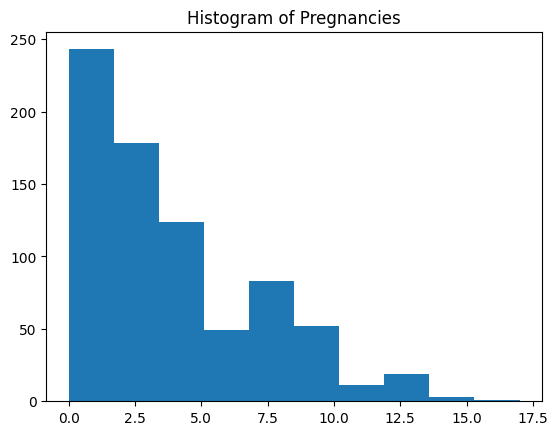

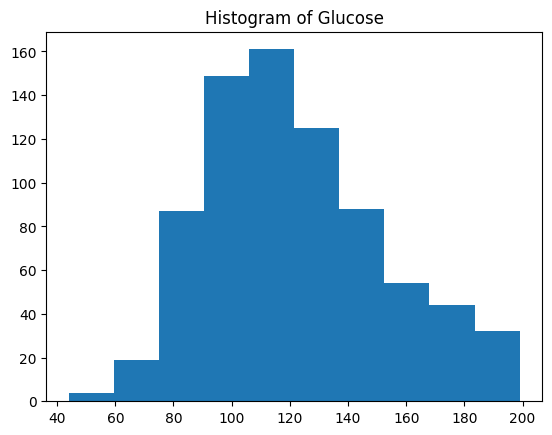

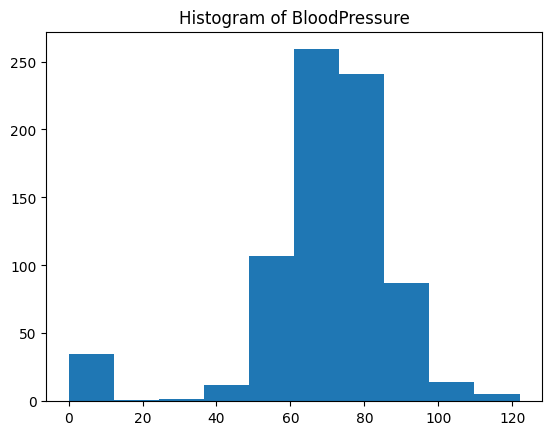

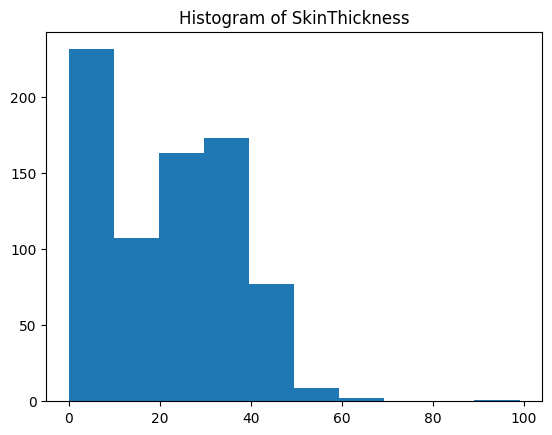

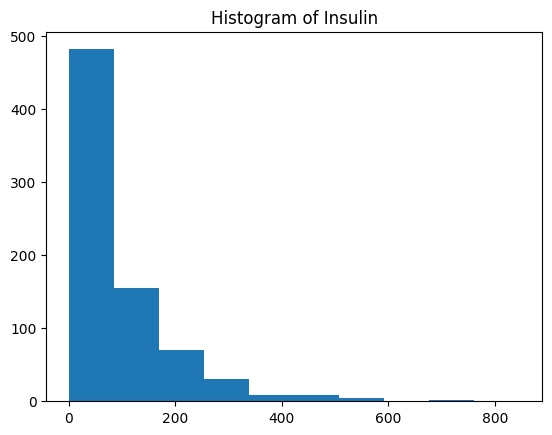

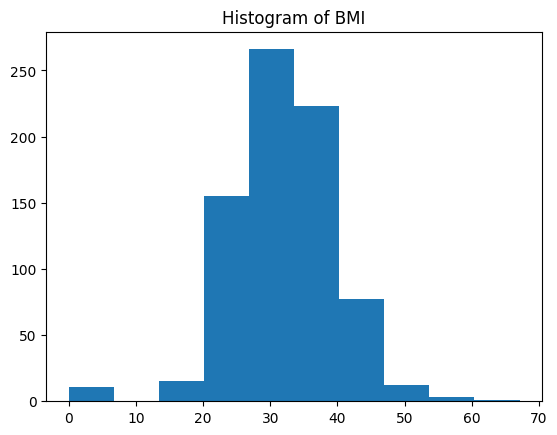

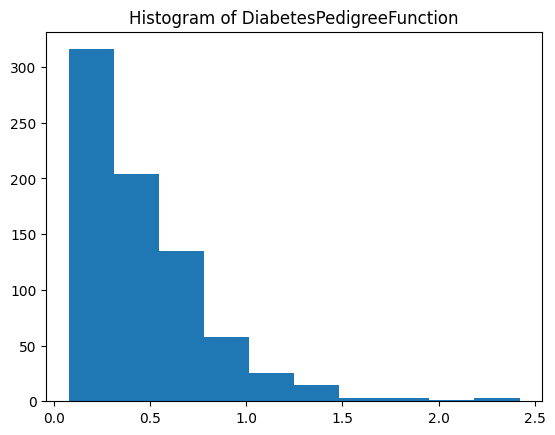

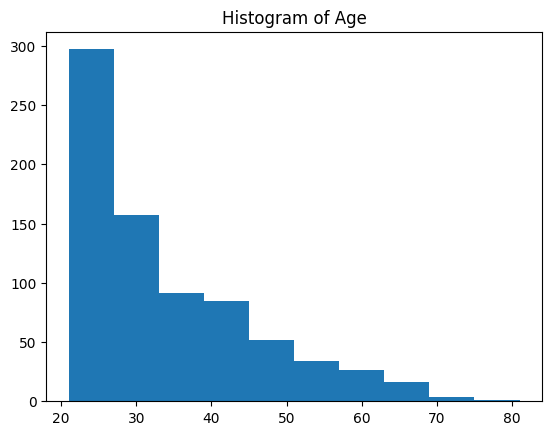

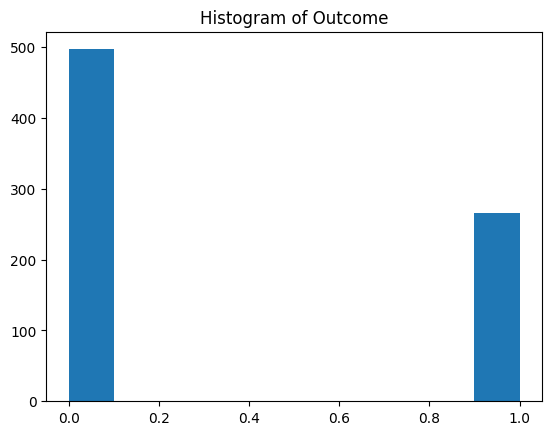

In [ ]:
plot_histograms(df)

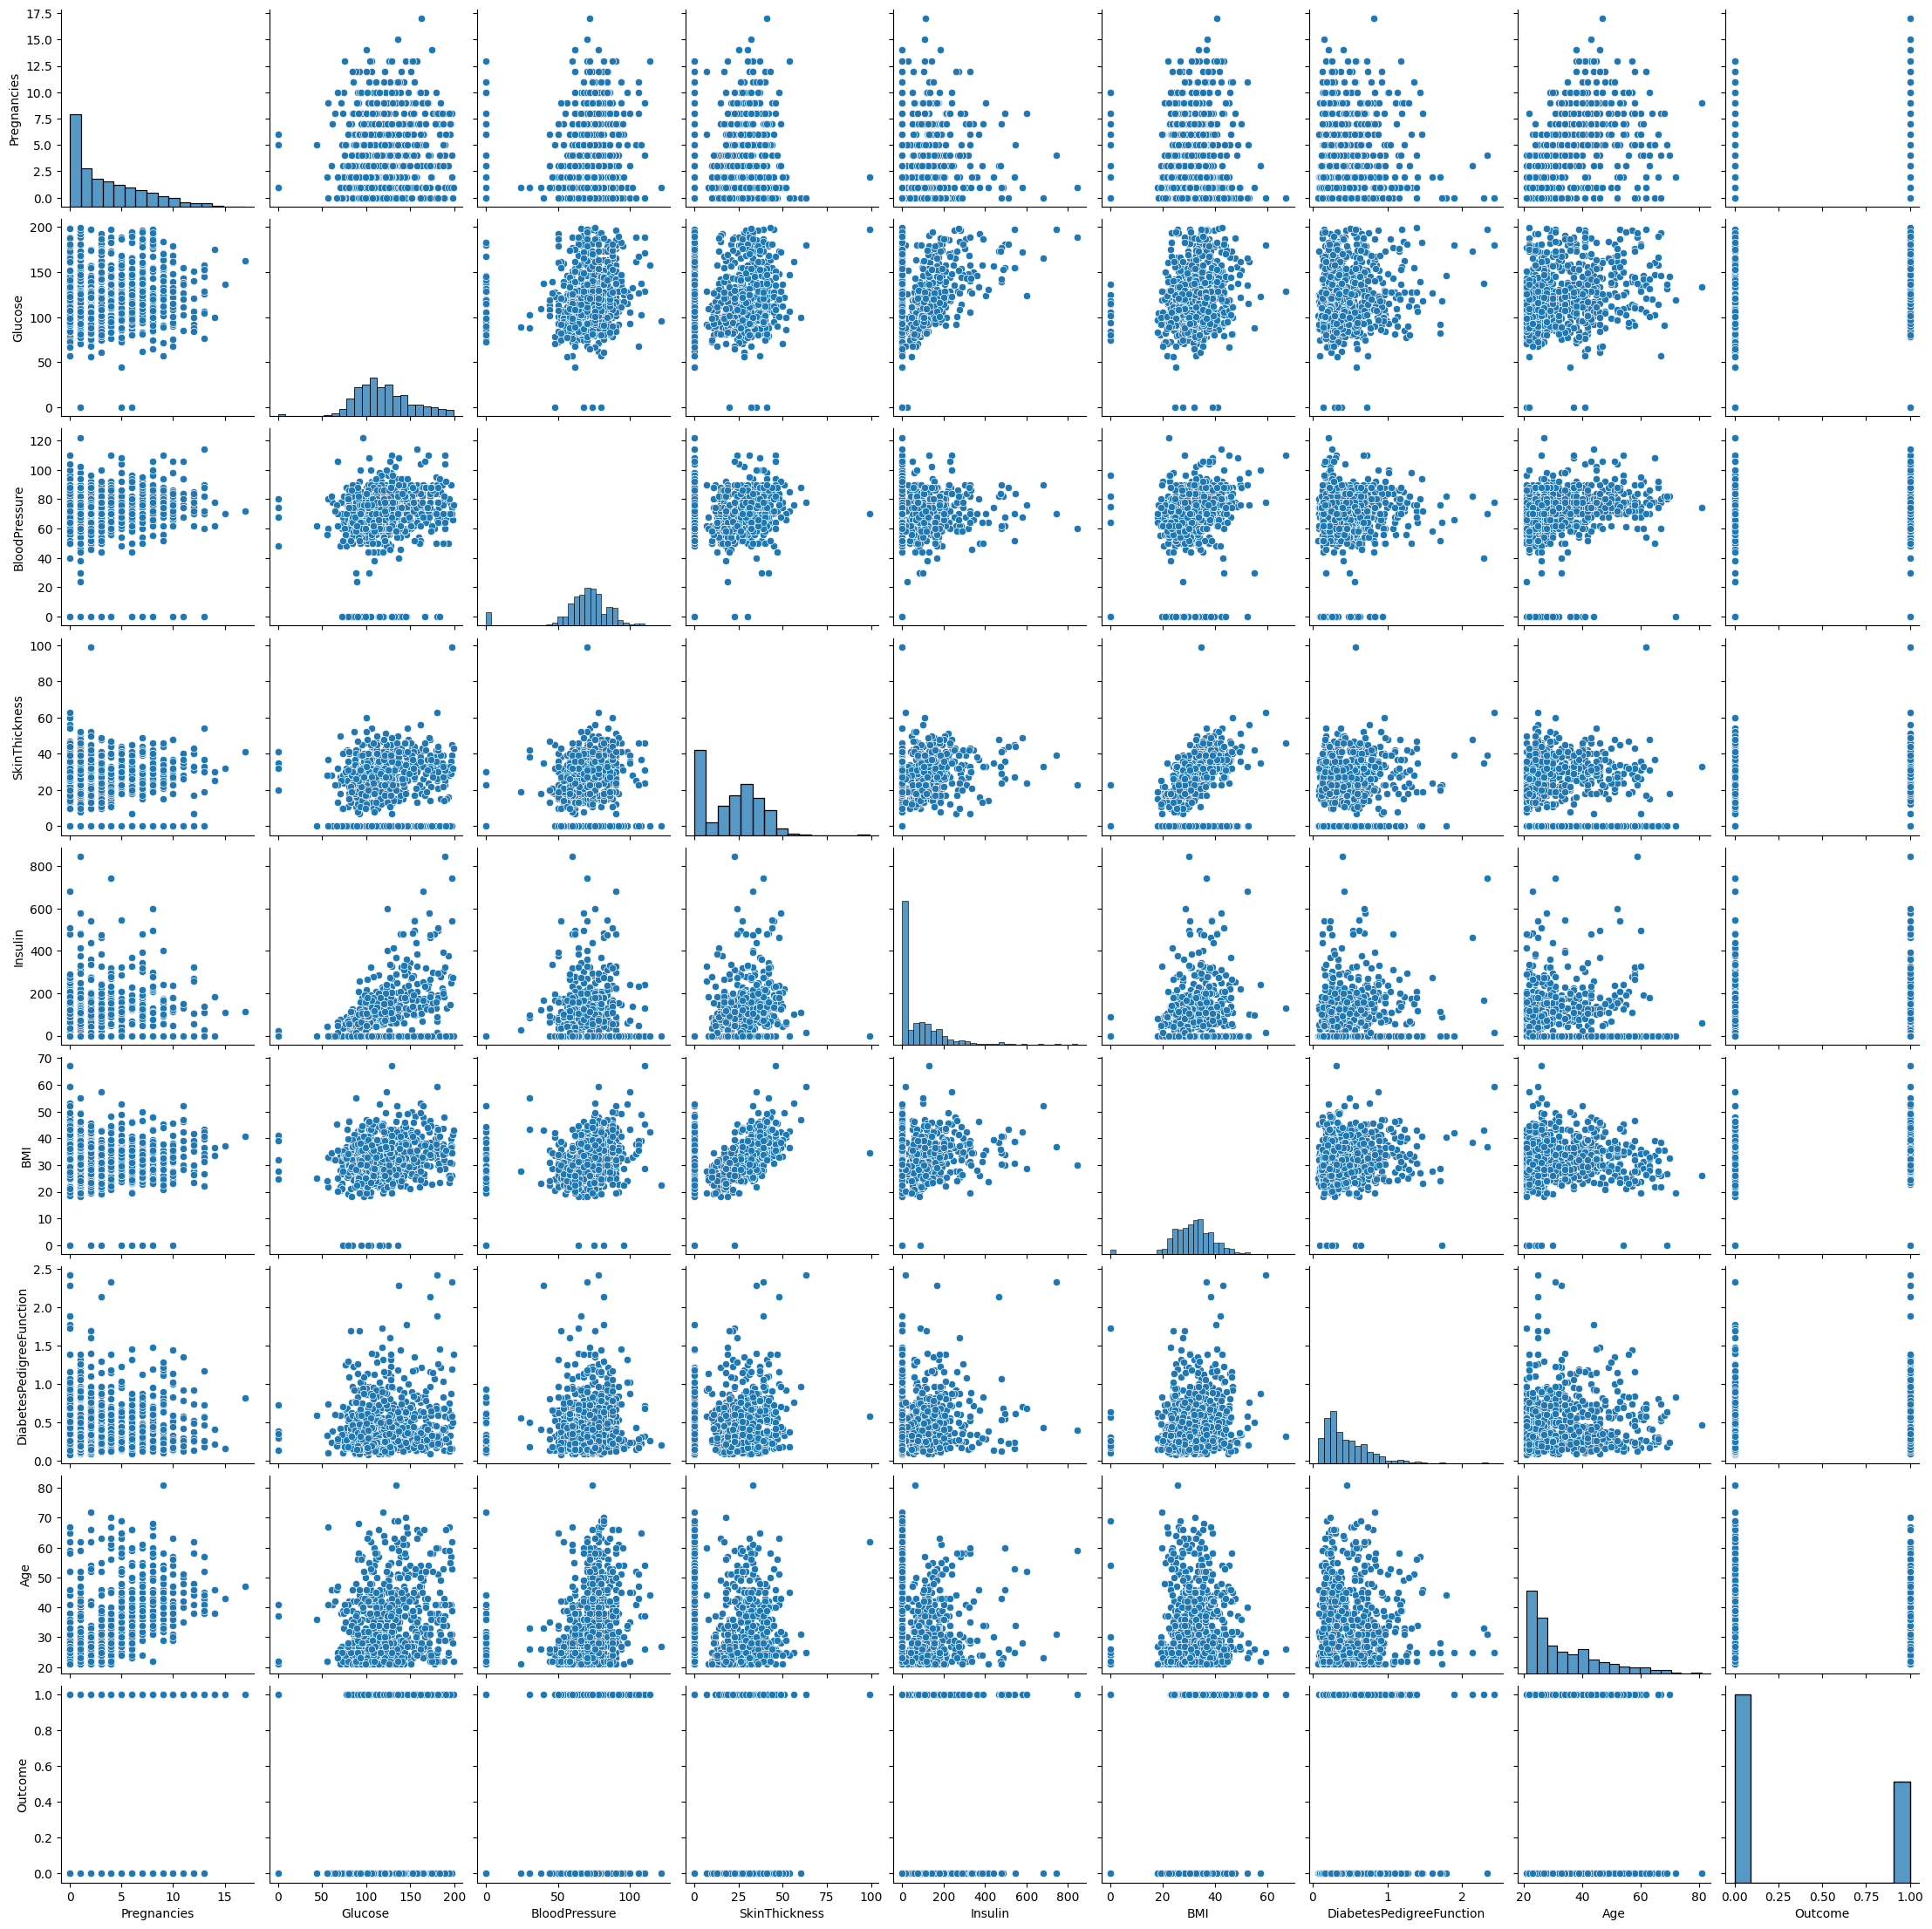

In [ ]:
plot_scatter_matrix(df)

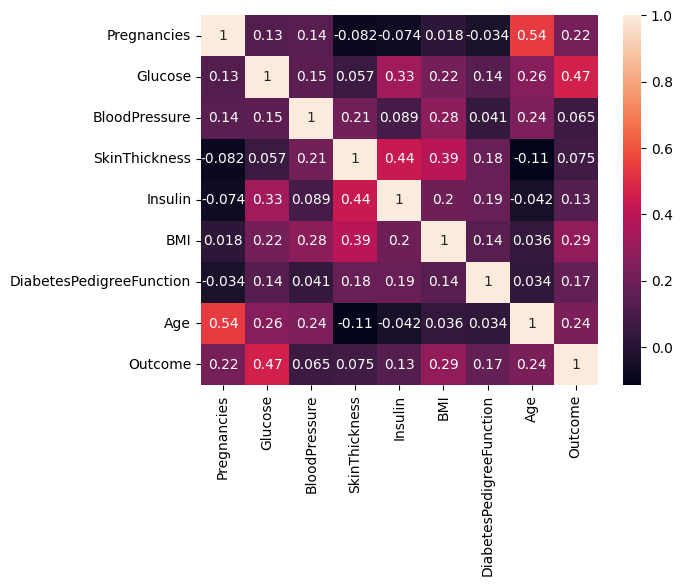

In [ ]:
plot_correlation_matrix(df)

**Data Cleaning:**

*   Handle Missing Values: Imputation or removal of missing data.
*   Remove Duplicates: Remove duplicate rows in the data
*   Reduce Noise: Identify and handle outliers or noisy data points.

In [ ]:
from sklearn.impute import SimpleImputer

# Handles missing values in the DataFrame using SimpleImputer
def handle_missing_values(df, strategy='mean'):
  imputer = SimpleImputer(strategy=strategy)
  df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
  return df_imputed

# As we saw there is no missing values, so no need to handle missing values.
# df = handle_missing_values(df, "mean")

# As there is no duplicate entry so we don't require this too
# df_cleaned = df.drop_duplicates()

In [ ]:
import numpy as np

# Reduces noise in a specific column.
def reduce_noise(df, column, method='zscore', threshold=3):
  if method == 'zscore':
    z = np.abs((df[column] - df[column].mean()) / df[column].std())
    df = df[(z < threshold)]
  elif method == 'iqr':
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  return df

df = reduce_noise(df.copy(), "BloodPressure", "iqr", 1.5)

**Data Transformation:**

In some cases, we might need to transform your data to make it suitable for your model. Common transformations include:
**Scaling**: Bringing features to a similar scale (e.g., using StandardScaler or MinMaxScaler).
**Encoding**: Converting categorical features into numerical representations (e.g., using OneHotEncoder or LabelEncoder).
**Log Transformation**: Applying a logarithm to skewed data to make it more normal

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
# Encodes categorical features using Label Encoding.
def encode_categorical_features(df, categorical_cols):
  for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
  return df

# Scales numerical features using StandardScaler or MinMaxScaler.
def scale_features(df, numerical_cols, method='standard'):
  # Create a copy to avoid the warning
  df_scaled = df.copy()

  if method == 'standard':
    scaler = StandardScaler()
  elif method == 'minmax':
    scaler = MinMaxScaler()

  df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])
  return df_scaled



---



**Part A**


**Q1.a)** **Find the optimum number of principal components for the features in the above-mentioned data**

Optimal number of components: 8


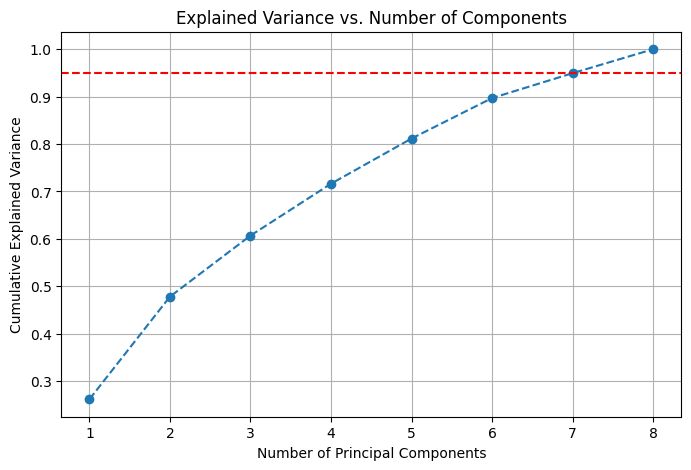

(np.int64(8), StandardScaler())

In [ ]:
# PCA plotting
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def find_optimal_pca_components(X):
  # Separate features and target
  X = df.drop(columns=["Outcome"])
  y = df["Outcome"]

  # Standardize the features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  # Apply PCA
  pca = PCA()
  X_pca = pca.fit_transform(X_scaled)

  # Explained variance ratio
  explained_variance = np.cumsum(pca.explained_variance_ratio_)

  # Find the optimal number of components (95% variance)
  optimal_components = np.argmax(explained_variance >= 0.95) + 1
  print(f"Optimal number of components: {optimal_components}")

  # Plot explained variance
  plt.figure(figsize=(8, 5))
  plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
  plt.axhline(y=0.95, color='r', linestyle='--')
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.title('Explained Variance vs. Number of Components')
  plt.grid()
  plt.show()
  return optimal_components, scaler

features = df.drop(columns=["Outcome"])
target = df["Outcome"]
optimal_components, scaler = find_optimal_pca_components(features)

**Q1. b)** Use any two regression models of your choice and find the prediction accuracy and error between the reduced data (with an optimum number of principal components) and the complete data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error

def train_and_evaluate_models(X, y, optimal_components, scaler):
 X_scaled = scaler.transform(X)
 pca_optimal = PCA(n_components=optimal_components)
 X_reduced = pca_optimal.fit_transform(X_scaled)

 X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
 X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
 models = {
     "Logistic Regression": LogisticRegression(),
     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }
 results = {}
 for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc_original = accuracy_score(y_test, y_pred)
  mae_original = mean_absolute_error(y_test, y_pred)

  model.fit(X_train_pca, y_train_pca)
  y_pred_pca = model.predict(X_test_pca)
  acc_pca = accuracy_score(y_test_pca, y_pred_pca)
  mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)

  results[name] = {
      "Accuracy (Original)": acc_original,
      "MAE (Original)": mae_original,
      "Accuracy (PCA)": acc_pca,
      "MAE (PCA)": mae_pca
      }
 return results

results = train_and_evaluate_models(features, target, optimal_components, scaler)

for model, res in results.items():
  print(f"{model}:")
  print(f"  Accuracy (Original): {res['Accuracy (Original)']:.4f}")
  print(f"  MAE (Original): {res['MAE (Original)']:.4f}")
  print(f"  Accuracy (PCA): {res['Accuracy (PCA)']:.4f}")
  print(f"  MAE (PCA): {res['MAE (PCA)']:.4f}\n")

Logistic Regression:
  Accuracy (Original): 0.7532
  MAE (Original): 0.2468
  Accuracy (PCA): 0.7532
  MAE (PCA): 0.2468

Random Forest:
  Accuracy (Original): 0.7208
  MAE (Original): 0.2792
  Accuracy (PCA): 0.7273
  MAE (PCA): 0.2727





---



**Q2:** We will use the fashion-MNIST dataset for this question (you can download it from any other source also including libraries). Flatten and preprocess the data (if required) before starting the tasks. It will become a 784-dimensional data with 10 classes, more details are available in the link.

In [ ]:
!pip install -q -U keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import keras

fashion_mnist = keras.datasets.fashion_mnist
fashion_db = fashion_mnist.load_data()

**a)** Train the k-means model on f-MNIST data with k = 10 and 10 random 784-dimensional
points (in input range) as initializations. **Report the number of points in each cluster.**

In [ ]:
from sklearn.cluster import KMeans

# Trains a k-means model on the Fashion-MNIST data with k clusters
# and reports the number of points in each cluster.
def train_kmeans_and_report_cluster_counts(train_images, k=10):
    # Reshape the images to 784-dimensional vectors
    train_images_flattened = train_images.reshape(train_images.shape[0], -1)

    # Normalize pixel values to the range [0, 1]
    train_images_flattened = train_images_flattened / 255.0

    # Generate k random initial points within the input range
    initial_centroids = np.random.rand(k, 784)

    # Create and train the k-means model
    kmeans = KMeans(n_clusters=k, init=initial_centroids, n_init=1)
    kmeans.fit(train_images_flattened)

    # Get cluster labels for each data point
    cluster_labels = kmeans.labels_

    # Count the number of points in each cluster
    cluster_counts = np.bincount(cluster_labels)

    # Print the cluster counts
    for i, count in enumerate(cluster_counts):
        print(f"Cluster {i}: {count} points")
    return kmeans

In [ ]:
import tensorflow as tf

from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = fashion_db

In [ ]:
kmeans = train_kmeans_and_report_cluster_counts(train_images)  # Uses default k=10

Cluster 0: 2541 points
Cluster 1: 5224 points
Cluster 2: 7526 points
Cluster 3: 7760 points
Cluster 4: 9703 points
Cluster 5: 5819 points
Cluster 6: 7564 points
Cluster 7: 7782 points
Cluster 8: 3704 points
Cluster 9: 2377 points


***b) Visualize the cluster centers of each cluster as 2D images of all clusters.***

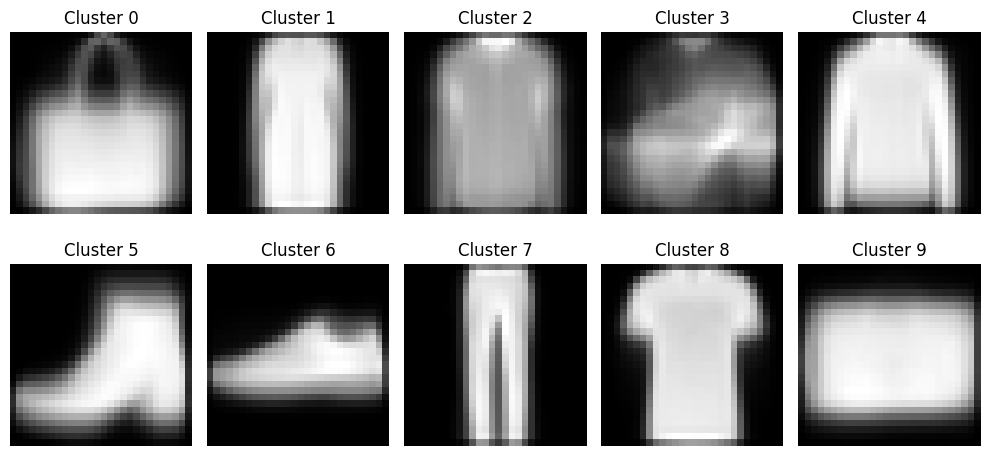

In [ ]:
import matplotlib.pyplot as plt

def visualize_cluster_centers(kmeans):
    """
    Visualizes the cluster centers of a k-means model as 2D images.

    Args:
        kmeans: The trained k-means model.

    Returns:
        None
    """
    cluster_centers = kmeans.cluster_centers_

    # Reshape cluster centers to 28x28 images
    cluster_centers_images = cluster_centers.reshape(-1, 28, 28)

    # Plot the cluster center images
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(cluster_centers_images[i], cmap='gray')
        ax.set_title(f"Cluster {i}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_cluster_centers(kmeans)

**c) Visualize 10 images corresponding to each cluster.**

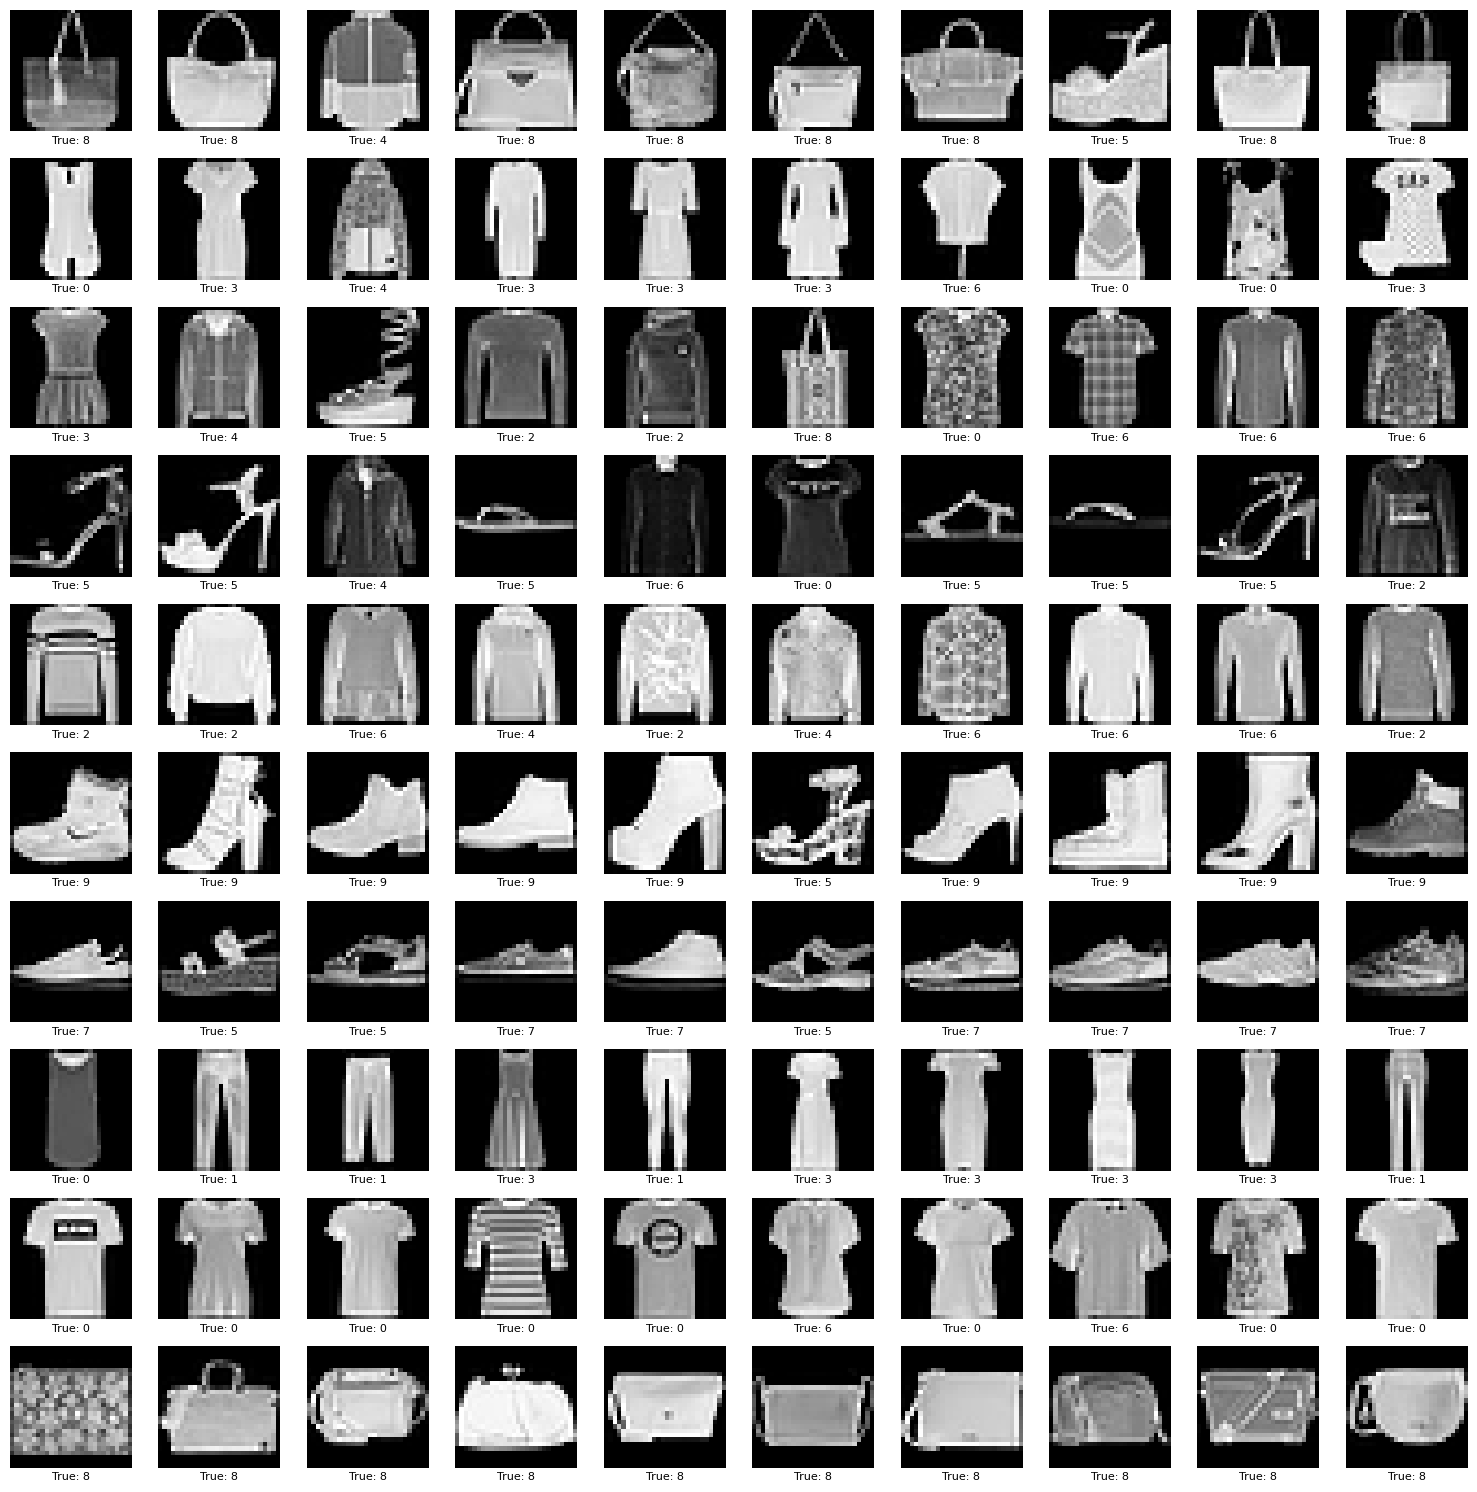

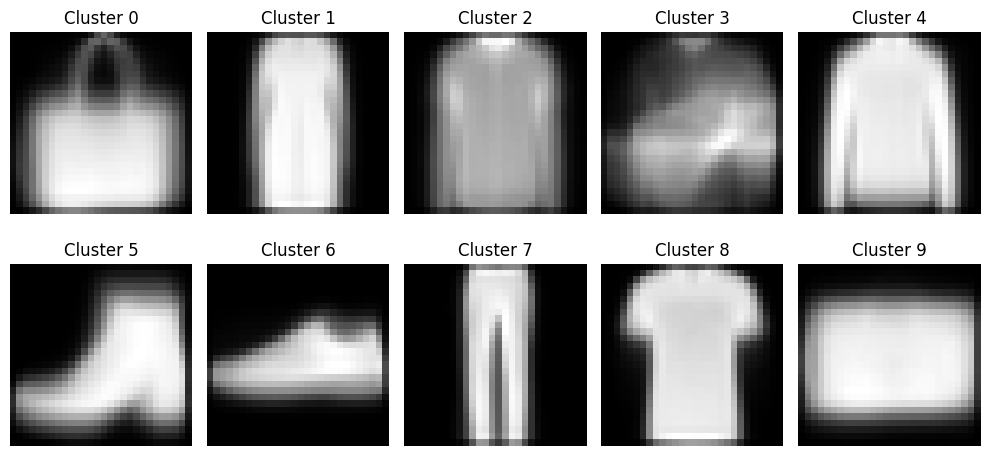

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_cluster_images(kmeans, train_images, train_labels, num_images_per_cluster=10):
    # Get cluster labels for each data point
    cluster_labels = kmeans.labels_

    # Reshape the images to 28x28
    train_images = train_images.reshape(-1, 28, 28)

    # Create a dictionary to store images for each cluster
    cluster_images = {i: [] for i in range(kmeans.n_clusters)}

    # Assign images to their respective clusters
    for i, label in enumerate(cluster_labels):
        if len(cluster_images[label]) < num_images_per_cluster:
            cluster_images[label].append(train_images[i])

    # Plot the images for each cluster
    fig, axes = plt.subplots(kmeans.n_clusters, num_images_per_cluster, figsize=(15, 15))
    for cluster, images in cluster_images.items():
        for i, image in enumerate(images):
            ax = axes[cluster, i]
            ax.imshow(image, cmap='gray')
            ax.axis('off')
            # Add the true label as text below the image
            true_label = train_labels[np.where(cluster_labels == cluster)[0][i]]
            ax.text(0.5, -0.1, f"True: {true_label}", size=8, ha="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

visualize_cluster_images(kmeans, train_images, train_labels)
visualize_cluster_centers(kmeans)

**d) Train another k-means model with 10 images from each class as initializations , report the
number of points in each cluster, and visualize the cluster centers.**

Cluster 0: 7526 points
Cluster 1: 7782 points
Cluster 2: 3704 points
Cluster 3: 5224 points
Cluster 4: 9703 points
Cluster 5: 7564 points
Cluster 6: 7760 points
Cluster 7: 5819 points
Cluster 8: 2541 points
Cluster 9: 2377 points


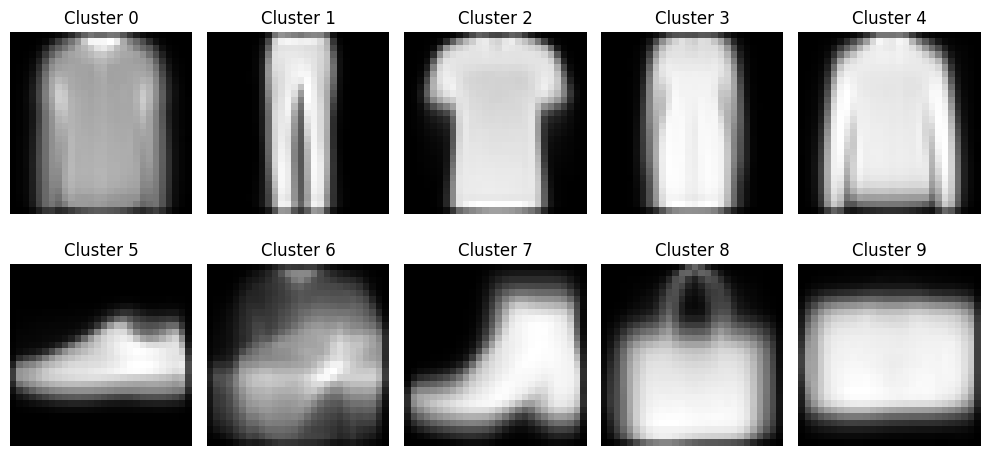

In [ ]:
def train_kmeans_with_class_images(train_images, train_labels, k=10):
    # Reshape the images to 784-dimensional vectors
    train_images_flattened = train_images.reshape(train_images.shape[0], -1)

    # Normalize pixel values to the range [0, 1]
    train_images_flattened = train_images_flattened / 255.0

    # Select 1 image from each class as initial centroids
    initial_centroids = []
    for i in range(k):
        class_indices = np.where(train_labels == i)[0]
        centroid_index = np.random.choice(class_indices, size=1, replace=False)
        initial_centroids.append(train_images_flattened[centroid_index[0]])

    initial_centroids = np.array(initial_centroids)

    # Create and train the k-means model
    kmeans = KMeans(n_clusters=k, init=initial_centroids, n_init=1)  # Use initial_centroids here
    kmeans.fit(train_images_flattened)

    # Get cluster labels for each data point
    cluster_labels = kmeans.labels_

    # Count the number of points in each cluster
    cluster_counts = np.bincount(cluster_labels)

    # Print the cluster counts
    for i, count in enumerate(cluster_counts):
        print(f"Cluster {i}: {count} points")

    # Visualize the cluster centers
    visualize_cluster_centers(kmeans)
    return kmeans

kmeans = train_kmeans_with_class_images(train_images, train_labels)


**e) Visualize 10 images corresponding to each cluster.**

Cluster 0: 6087 points
Cluster 1: 5249 points
Cluster 2: 6102 points
Cluster 3: 5199 points
Cluster 4: 7999 points
Cluster 5: 7883 points
Cluster 6: 4246 points
Cluster 7: 7701 points
Cluster 8: 3710 points
Cluster 9: 5824 points


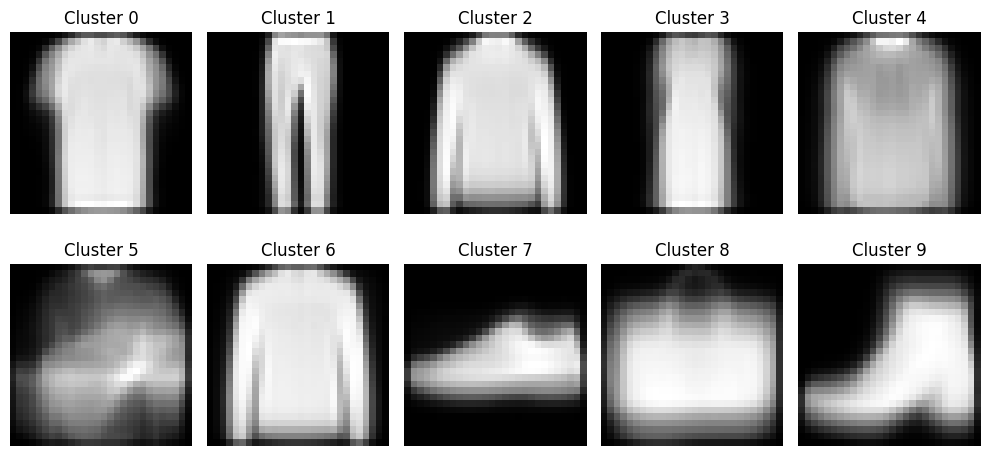

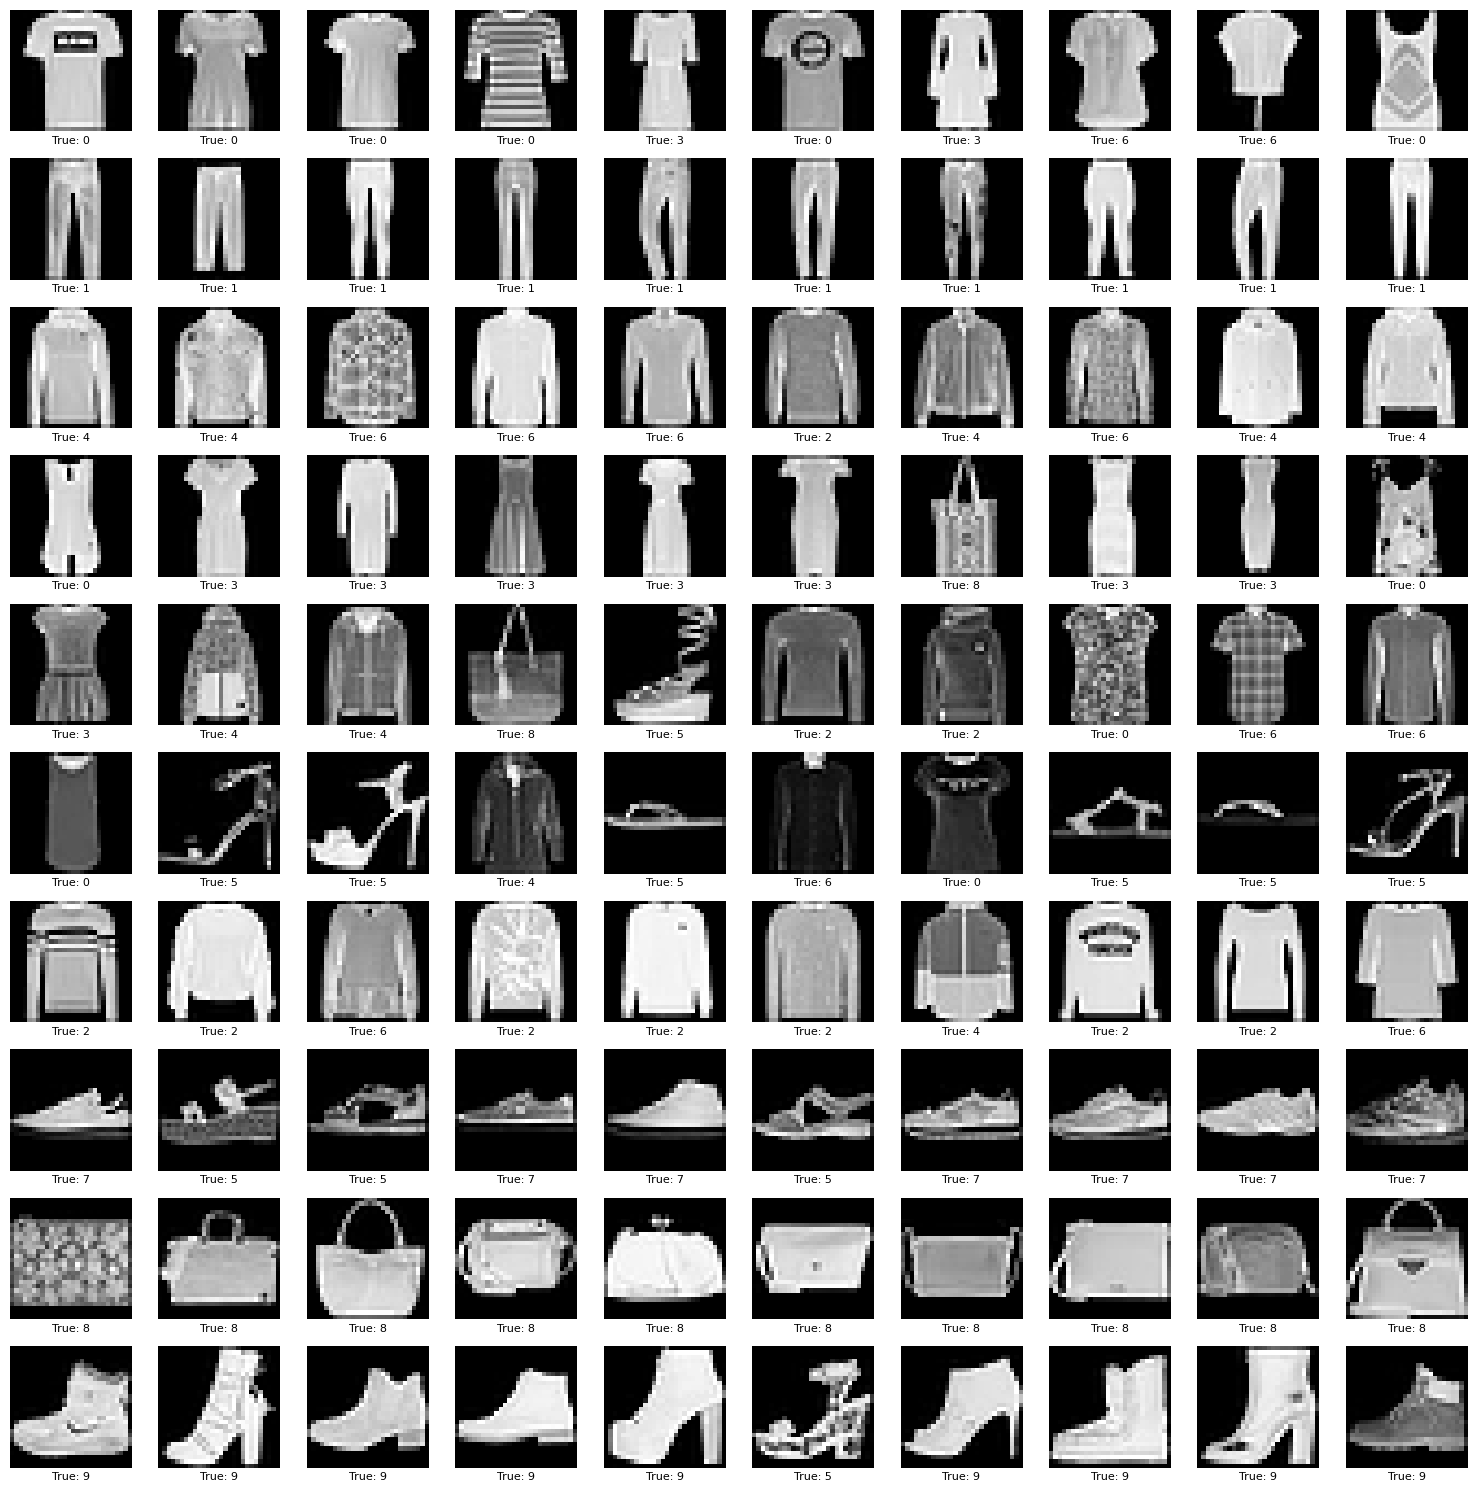

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizes images corresponding to each cluster.
def visualize_cluster_images(kmeans, train_images, train_labels, num_images_per_cluster=10):
    # Get cluster labels for each data point
    cluster_labels = kmeans.labels_

    # Reshape the images to 28x28
    train_images = train_images.reshape(-1, 28, 28)

    # Create a dictionary to store images for each cluster
    cluster_images = {i: [] for i in range(kmeans.n_clusters)}

    # Assign images to their respective clusters
    for i, label in enumerate(cluster_labels):
        if len(cluster_images[label]) < num_images_per_cluster:
            cluster_images[label].append(train_images[i])

    # Plot the images for each cluster
    fig, axes = plt.subplots(kmeans.n_clusters, num_images_per_cluster, figsize=(15, 15))
    for cluster, images in cluster_images.items():
        for i, image in enumerate(images):
            ax = axes[cluster, i]
            ax.imshow(image, cmap='gray')
            ax.axis('off')
            # Add the true label as text below the image
            true_label = train_labels[np.where(cluster_labels == cluster)[0][i]]
            ax.text(0.5, -0.1, f"True: {true_label}", size=8, ha="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

kmeans = train_kmeans_with_class_images(train_images, train_labels)
visualize_cluster_images(kmeans, train_images, train_labels, num_images_per_cluster=10)


**f) Evaluate Clusters of part a and part d with Sum of Squared Error (SSE) method. Report
the scores and comment on which case is a better clustering.**

Cluster 0: 3779 points
Cluster 1: 9526 points
Cluster 2: 7777 points
Cluster 3: 3768 points
Cluster 4: 3002 points
Cluster 5: 6581 points
Cluster 6: 4323 points
Cluster 7: 5167 points
Cluster 8: 8285 points
Cluster 9: 7792 points
SSE (Random Initialization): 1923341.1172638314
Cluster 0: 6381 points
Cluster 1: 5227 points
Cluster 2: 9546 points
Cluster 3: 5194 points
Cluster 4: 2537 points
Cluster 5: 5828 points
Cluster 6: 7307 points
Cluster 7: 7617 points
Cluster 8: 2361 points
Cluster 9: 8002 points


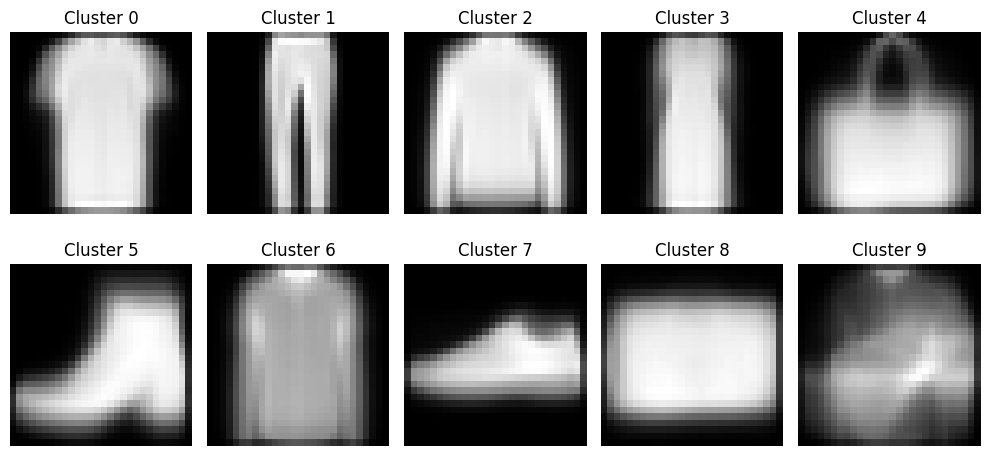

SSE (Class-Based Initialization): 1919628.5190576117
Clustering with class-based initialization has a lower SSE and is potentially better.


In [ ]:
# Calculates the Sum of Squared Error (SSE) for a k-means model.
def calculate_sse(kmeans, data):
    return kmeans.inertia_

# Part (a): Train k-means with random initializations
kmeans_random = train_kmeans_and_report_cluster_counts(train_images)
sse_random = calculate_sse(kmeans_random, train_images.reshape(train_images.shape[0], -1) / 255.0)
print(f"SSE (Random Initialization): {sse_random}")

# Part (d): Train k-means with class-based initializations
kmeans_class_based = train_kmeans_with_class_images(train_images, train_labels)
sse_class_based = calculate_sse(kmeans_class_based, train_images.reshape(train_images.shape[0], -1) / 255.0)
print(f"SSE (Class-Based Initialization): {sse_class_based}")

# Compare SSE scores
if sse_random < sse_class_based:
    print("Clustering with random initialization has a lower SSE and is potentially better.")
else:
    print("Clustering with class-based initialization has a lower SSE and is potentially better.")



---



**Q3: Implementation of Neural Networks from Scratch Using NumPy and Comparison with
Sklearn**

**a) Load and preprocess the MNIST Digits Dataset.**

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import train_test_split

def load_mnist():
    # Load MNIST dataset
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data.astype(np.float32)
    y = mnist.target.astype(np.int32)
    print("Dataset loaded successfully!")
    return X, y

def preprocess_mnist(X):
    # Normalize pixel values to [0,1]
    X /= 255.0
    print("Data normalized!")
    return X

def split_mnist_data(X, y, test_size=1/7, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print("Training set size:", X_train.shape)
    print("Testing set size:", X_test.shape)
    return X_train, X_test, y_train, y_test

# Call the methods
X, y = load_mnist()
X = preprocess_mnist(X)
X_train, X_test, y_train, y_test = split_mnist_data(X, y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)


Dataset loaded successfully!
Data normalized!
Training set size: (60000, 784)
Testing set size: (10000, 784)


**b) Implement a neural network with one input layer, one hidden layer, and one output layer using NumPy.**

In [ ]:
def initialize_network(input_size, hidden_size, output_size):
    np.random.seed(42)  # For reproducibility
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)
    b2 = np.zeros((1, output_size))
    print("Network initialized with Xavier Initialization!")
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    print("Forward propagation completed!")
    return A1, A2

W1, b1, W2, b2 = initialize_network(input_size=784, hidden_size=128, output_size=10)
A1, A2 = forward_propagation(X_train, W1, b1, W2, b2)


Network initialized with Xavier Initialization!
Forward propagation completed!


**c) Train the neural network with various hyperparameters (e.g., learning rate, number of
hidden nodes).**

In [ ]:
def train_neural_network(X, y, W1, b1, W2, b2, learning_rate=0.001, epochs=1000):

    def sigmoid(z):
      z = np.clip(z, -500, 500)  # Prevents overflow in exp()
      return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(A):
        return A * (1 - A)  # Correct derivative using output, not input

    y_one_hot = np.eye(10)[y]  # Convert labels to one-hot encoding
    y_train_one_hot = np.eye(10)[y_train]
    y_val_one_hot = np.eye(10)[y_val]
    train_loss, val_loss, train_acc, val_acc = [], [], [], []


    for epoch in range(epochs):
        # Forward propagation
        Z1 = np.dot(X, W1) + b1
        A1 = sigmoid(Z1)
        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        # Compute loss (Mean Squared Error)
        loss = np.mean((y_one_hot - A2) ** 2)
         # Compute training loss & accuracy
        train_loss.append(np.mean((y_train_one_hot - A2) ** 2))
        train_acc.append(np.mean(np.argmax(A2, axis=1) == y_train) * 100)

        # Forward propagation (Validation)
        Z1_val = np.dot(X_val, W1) + b1
        A1_val = sigmoid(Z1_val)
        Z2_val = np.dot(A1_val, W2) + b2
        A2_val = sigmoid(Z2_val)

        # Compute validation loss & accuracy
        val_loss.append(np.mean((y_val_one_hot - A2_val) ** 2))
        val_acc.append(np.mean(np.argmax(A2_val, axis=1) == y_val) * 100)

        # Backpropagation
        dA2 = (A2 - y_one_hot) * sigmoid_derivative(A2)
        dW2 = np.dot(A1.T, dA2)
        db2 = np.sum(dA2, axis=0, keepdims=True)

        dA1 = np.dot(dA2, W2.T) * sigmoid_derivative(A1)
        dW1 = np.dot(X.T, dA1)
        db1 = np.sum(dA1, axis=0, keepdims=True)

        # Gradient Clipping to prevent exploding gradients
        np.clip(dW1, -1, 1, out=dW1)
        np.clip(dW2, -1, 1, out=dW2)

        # Gradient Descent update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.6f}")

    print("Training completed!")
    return W1, b1, W2, b2, train_loss, val_loss, train_acc, val_acc

# Call the training function
W1, b1, W2, b2, train_loss_np, val_loss_np, train_acc_np, val_acc_np = train_neural_network(X_train, y_train, W1, b1, W2, b2)

# Save NumPy model parameters
np.save("W1.npy", W1)
np.save("b1.npy", b1)
np.save("W2.npy", W2)
np.save("b2.npy", b2)

# Save losses & accuracies
np.save("train_loss.npy", train_loss_np)
np.save("val_loss.npy", val_loss_np)
np.save("train_acc.npy", train_acc_np)
np.save("val_acc.npy", val_acc_np)

Epoch 0, Loss: 0.268329
Training completed!


**d) Evaluate the performance of the neural network on the testing set.**

In [ ]:
def predict(X, W1, b1, W2, b2):
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))  # Stable sigmoid function

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return np.argmax(A2, axis=1)  # Return the index of the highest probability

def evaluate_model(X_test, y_test, W1, b1, W2, b2):
    y_pred = predict(X_test, W1, b1, W2, b2)
    accuracy = np.mean(y_pred == y_test) * 100  # Calculate accuracy
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

numpy_accuracy = evaluate_model(X_test, y_test, W1, b1, W2, b2)

Test Accuracy: 85.95%


In [ ]:
from sklearn.metrics import confusion_matrix

def confusion_matrix_analysis(X_test, y_test, W1, b1, W2, b2):
    y_pred = predict(X_test, W1, b1, W2, b2)
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

confusion_matrix_analysis(X_test, y_test, W1, b1, W2, b2)


Confusion Matrix:
 [[ 965    0    2    0    1    2    7    1    5    0]
 [   0 1128    4    7    1    1    0    5    5    1]
 [   6    7  919    4    5    3    7    9    6    1]
 [   0    2   11  981    2    9    2   10    8    9]
 [   3    0    1    1  869    0    8    3    2   19]
 [   2    0    0   19    5  896    6    0    5    4]
 [   4    2    0    0    5    6  942    0    2    0]
 [   0    6    8    0    4    2    0 1023    1   11]
 [   2    5    7   19    5    4    4    6  914    3]
 [   5    4    0   12   22    2    0    7   12  972]]


**e) Implement the same neural network using sklearn and compare the results with the
NumPy implementation.**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
import numpy as np

def train_sklearn_nn(X_train, y_train, X_val, y_val, epochs=10, learning_rate=0.01, batch_size=200):
    model = MLPClassifier(
        hidden_layer_sizes=(128,), activation='logistic', solver='sgd',
        learning_rate_init=learning_rate, max_iter=50, warm_start=True,
        random_state=42, batch_size=batch_size, tol=1e-4,
        early_stopping=True, n_iter_no_change=5
    )

    train_loss, val_loss, train_acc, val_acc = [], [], [], []

    for epoch in range(epochs):
        model.fit(X_train, y_train)  # Train with more iterations per epoch

        # Record training loss
        if hasattr(model, "loss_"):
            train_loss.append(model.loss_)

        # Compute validation loss using log_loss
        y_val_proba = model.predict_proba(X_val)
        val_loss.append(log_loss(y_val, y_val_proba))

        # Compute accuracy
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        train_acc.append(np.mean(train_pred == y_train) * 100)
        val_acc.append(np.mean(val_pred == y_val) * 100)

        if epoch % 5 == 0:  # Log every 5 epochs
            print(f"Epoch {epoch}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Accuracy: {val_acc[-1]:.2f}%")

    return model, train_loss, val_loss, train_acc, val_acc

# Train the model
sklearn_model, train_loss_sklearn, val_loss_sklearn, train_acc_sklearn, val_acc_sklearn = train_sklearn_nn(X_train, y_train, X_val, y_val)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 0, Train Loss: 0.1608, Val Loss: 0.1700, Val Accuracy: 95.10%
Epoch 5, Train Loss: 0.1486, Val Loss: 0.1595, Val Accuracy: 95.55%


In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_sklearn_nn(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    print(f"Sklearn NN Test Accuracy: {accuracy:.2f}%")
    return accuracy

# Evaluate sklearn NN
sklearn_accuracy = evaluate_sklearn_nn(sklearn_model, X_test, y_test)


Sklearn NN Test Accuracy: 95.03%


**f) Plot the training and validation loss/accuracy curves (for both experiments).**

In [ ]:
import matplotlib.pyplot as plt

def plot_curves(train_loss, val_loss, train_acc, val_acc, title):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', color='blue')
    plt.plot(epochs, val_loss, label='Val Loss', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss Curve')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Val Accuracy', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{title} - Accuracy Curve')
    plt.legend()

    plt.show()

Compare Results

In [ ]:
print(f"NumPy NN Accuracy: {numpy_accuracy:.2f}%")

NumPy NN Accuracy: 85.95%


In [ ]:
print(f"Sklearn NN Accuracy: {sklearn_accuracy:.2f}%")

Sklearn NN Accuracy: 95.03%


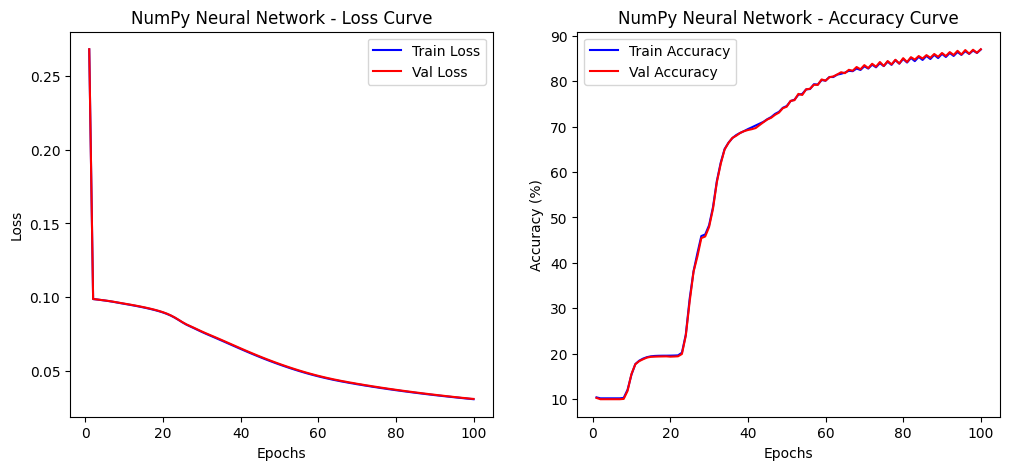

In [ ]:
plot_curves(train_loss_np, val_loss_np, train_acc_np, val_acc_np, "NumPy Neural Network")

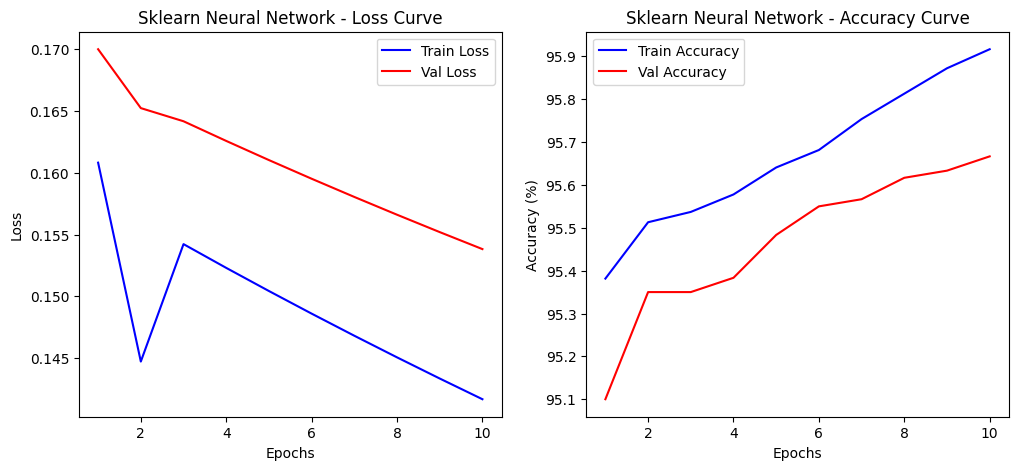

In [ ]:
plot_curves(train_loss_sklearn, val_loss_sklearn, train_acc_sklearn, val_acc_sklearn, "Sklearn Neural Network")
